# 03 — Results Aggregation (PGR207 CIFAR-10 mid-term)

**Student IDs:** `<STUDENT_ID_1>`, `<STUDENT_ID_2>` *(fill in before submitting)*

Reads `all_results.csv` (one row per training run, written by `02_full_experiment.ipynb`) and
produces every table and figure in the Results section of the paper. Nothing here trains a
model, and nothing touches the test set again. All logic lives in `pipeline_metrics.py`
(numbers) and `pipeline_plots.py` (figures), so this notebook only calls and displays.

| Output | Paper | Brief |
|---|---|---|
| `tables/table_architecture.tex`, `..._augmentation.tex`, `..._optimizer.tex` | Tables I–III | §3.5 Step 4, §8 Results |
| `tables/table_per_class.tex` | Table IV | §5 Required metrics |
| `figures/fig1_effect_sizes` | Fig. 1 | §5 Comparing fairly, §10 Results & discussion |
| `figures/fig2a_val_accuracy`, `fig2b_augmentation_loss` | Fig. 2 | §5 Training curves |
| `figures/fig3_confusion` | Fig. 3 | §5 Required metrics |
| `figures/fig4_accuracy_vs_cost` | Fig. 4 (optional) | §8 Results, §10 top band |

Conventions (state these in the paper):
- Every metric is computed **per run first**, then averaged over the 3 seeds (mean ± sample std). Predictions are never pooled (§5, "Aggregating over seeds").
- F1, precision and recall are **macro**-averaged (§5, "Averaging").
- Confusion matrices are the **element-wise mean over the 3 seeds** (§5).

Run with **Kernel → Restart & Run All**, so no output depends on an earlier state of the kernel.

## 0. Setup

In [13]:
import pandas as pd

import pipeline_config as cfg
import pipeline_metrics as metrics
import pipeline_plots as plots

pd.set_option("display.width", 160)

## 1. Load and check the results file

`check_results_complete` stops the notebook if a run is missing or duplicated.

In [14]:
raw_df = metrics.load_results(cfg.RESULTS_CSV_DEFAULT)
metrics.check_results_complete(raw_df)
df = metrics.decode_json_columns(raw_df)

print(f"{len(df)} runs, GPU: {df['gpu'].unique().tolist()}")
df[["config_id", "architecture", "augmentation", "optimizer", "seed",
    "best_epoch", "test_accuracy", "test_macro_f1", "train_time_seconds"]]

21 runs, GPU: ['NVIDIA A100-SXM4-40GB']


,config_id,architecture,augmentation,optimizer,seed,best_epoch,test_accuracy,test_macro_f1,train_time_seconds
0,C1,resnet18,crop_flip,sgd,0,24,0.9205,0.920428,189.278504
1,C1,resnet18,crop_flip,sgd,1,25,0.9247,0.924831,146.566601
2,C1,resnet18,crop_flip,sgd,2,25,0.9255,0.925475,147.299233
3,C2,simple_cnn,crop_flip,sgd,0,25,0.8342,0.834169,102.459873
4,C2,simple_cnn,crop_flip,sgd,1,25,0.8398,0.839158,90.597626
5,C2,simple_cnn,crop_flip,sgd,2,25,0.8338,0.833308,90.129636
6,C3,densenet121,crop_flip,sgd,0,24,0.9395,0.939414,836.624759
7,C3,densenet121,crop_flip,sgd,1,25,0.9391,0.939037,704.163761
8,C3,densenet121,crop_flip,sgd,2,25,0.9377,0.937760,703.790466
9,C4,resnet18,none,sgd,0,24,0.8657,0.865599,144.682497


## 2. Per-configuration summary (mean ± std over seeds)

The single table everything below is built from. `delta_vs_C1_pp` is the difference to the
baseline in accuracy points; compare it with `accuracy_std` to judge whether a difference is
larger than the seed-to-seed noise (§4, "the spread across seeds is your noise floor").

In [15]:
summary = metrics.aggregate_over_seeds(df)
summary.round(4)

,config_id,architecture,augmentation,optimizer,num_params,n_seeds,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,test_loss_mean,train_time_mean,time_per_epoch_mean,best_epoch_min,best_epoch_max,delta_vs_C1_pp
0,C1,resnet18,crop_flip,sgd,11173962,3,0.9236,0.0027,0.9236,0.0027,0.2484,161.0481,6.4419,24,25,0.0000
1,C2,simple_cnn,crop_flip,sgd,620362,3,0.8359,0.0034,0.8355,0.0032,0.4841,94.3957,3.7758,25,25,-8.7633
2,C3,densenet121,crop_flip,sgd,6956426,3,0.9388,0.0009,0.9387,0.0009,0.2166,748.1930,29.9277,24,25,1.5200
3,C4,resnet18,none,sgd,11173962,3,0.8637,0.0044,0.8634,0.0046,0.4740,144.4876,5.7795,23,25,-5.9833
4,C5,resnet18,strong,sgd,11173962,3,0.9215,0.0031,0.9213,0.0031,0.2294,185.6936,7.4277,25,25,-0.2067
5,C6,resnet18,crop_flip,adam,11173962,3,0.9209,0.0029,0.9209,0.0031,0.3166,150.2663,6.0107,21,24,-0.2667
6,C7,resnet18,crop_flip,adamw,11173962,3,0.9067,0.0046,0.9065,0.0048,0.3337,149.9738,5.9990,17,20,-1.6867


## 3. Factor-study tables (Tables I–III)

One table per study with C1 in all three: the repetition is intended (§3.5, Step 4). Each is also
written to `tables/` as a `.tex` file to `\input{}` into the paper.

In [16]:
import os
os.makedirs(cfg.TABLES_DIR, exist_ok=True)

factor_tables = {}
for factor in cfg.FACTOR_STUDIES:
    factor_tables[factor] = metrics.build_factor_table(summary, factor)
    metrics.factor_table_to_latex(factor_tables[factor], factor,
                                  os.path.join(cfg.TABLES_DIR, f"table_{factor}.tex"))
    print(f"\n{factor.upper()} STUDY")
    display(factor_tables[factor])


ARCHITECTURE STUDY


,config_id,architecture,Params,Accuracy (%),Macro-F1,Δ vs C1 (pp),Time/epoch (s)
0,C2,Simple CNN,0.62 M,83.59 ± 0.34,0.836 ± 0.003,-8.76,3.8
1,C1,ResNet-18,11.17 M,92.36 ± 0.27,0.924 ± 0.003,—,6.4
2,C3,DenseNet-121,6.96 M,93.88 ± 0.09,0.939 ± 0.001,+1.52,29.9



AUGMENTATION STUDY


,config_id,augmentation,Params,Accuracy (%),Macro-F1,Δ vs C1 (pp),Time/epoch (s)
0,C4,None,11.17 M,86.37 ± 0.44,0.863 ± 0.005,-5.98,5.8
1,C1,Crop + flip,11.17 M,92.36 ± 0.27,0.924 ± 0.003,—,6.4
2,C5,Crop + flip + AutoAugment + erasing,11.17 M,92.15 ± 0.31,0.921 ± 0.003,-0.21,7.4



OPTIMIZER STUDY


,config_id,optimizer,Params,Accuracy (%),Macro-F1,Δ vs C1 (pp),Time/epoch (s)
0,C1,SGD (Nesterov),11.17 M,92.36 ± 0.27,0.924 ± 0.003,—,6.4
1,C6,Adam,11.17 M,92.09 ± 0.29,0.921 ± 0.003,-0.27,6.0
2,C7,AdamW,11.17 M,90.67 ± 0.46,0.907 ± 0.005,-1.69,6.0


## 4. Training dynamics in numbers

- **Train–val accuracy gap** at the last epoch: the brief asks whether this gap behaves as expected
  when augmentation gets stronger (§3.7).
- **Epoch at which validation accuracy first reaches 85 %**: evidence for the convergence-speed
  claim in the optimiser study (§3.7, "final accuracy, speed of convergence, or both?").

In [17]:
gap = metrics.train_val_gap(df)
conv = (metrics.convergence_epoch(df, threshold=0.85)
        .pivot(index="config_id", columns="seed", values="epoch_to_85pct")
        .add_prefix("seed_"))
gap.set_index("config_id").join(conv).round(1)

,train_val_gap_pp,seed_0,seed_1,seed_2
config_id,,,,
C1,5.6,14.0,13.0,15.0
C2,2.0,NaN,NaN,NaN
C3,5.2,10.0,11.0,9.0
C4,12.7,16.0,16.0,16.0
C5,-3.6,12.0,15.0,15.0
C6,6.3,11.0,10.0,12.0
C7,6.7,7.0,9.0,9.0


## 5. Fig. 1 — effect size vs seed-to-seed variation

Large marker = mean ± std, small dots = the three individual runs, dashed line = C1 mean. All
panels share one y-axis, so effect sizes can be compared across the three factors.

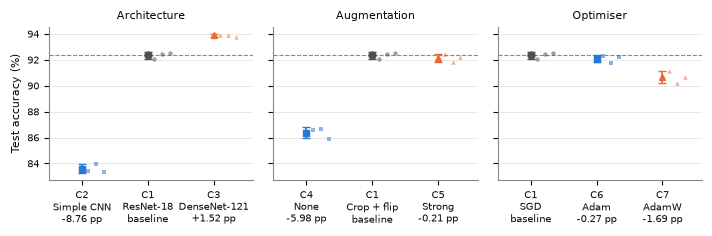

In [18]:
plots.plot_effect_sizes(df, summary);

## 6. Fig. 2 — training curves (mean over seeds, shaded ± std)

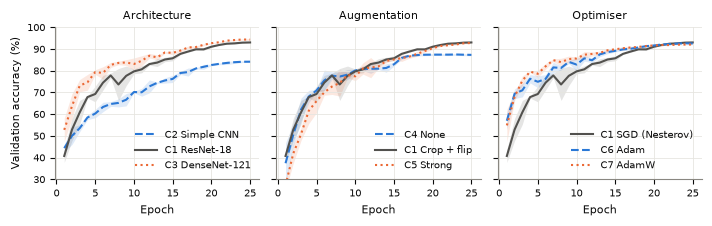

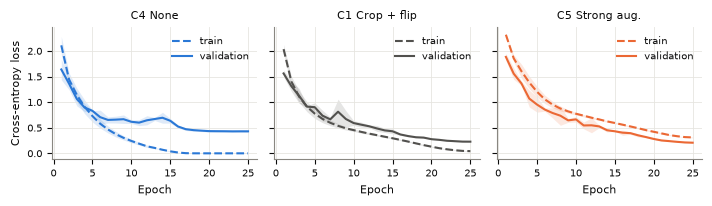

In [19]:
plots.plot_val_accuracy_curves(df);
plots.plot_augmentation_losses(df);

## 7. Best and worst configurations: per-class metrics (Table IV)

Best and worst by mean test accuracy. The brief requires per-class precision and recall for all ten
classes for at least these two (§5).

In [20]:
best_id, worst_id = metrics.best_worst_config_ids(summary)
print(f"Best: {best_id}   Worst: {worst_id}")

pc_best = metrics.per_class_table(df, best_id)
pc_worst = metrics.per_class_table(df, worst_id)
table_iv = pd.DataFrame({
    f"{best_id} precision": pc_best["precision_mean"], f"{best_id} recall": pc_best["recall_mean"],
    f"{worst_id} precision": pc_worst["precision_mean"], f"{worst_id} recall": pc_worst["recall_mean"],
})
table_iv.to_latex(os.path.join(cfg.TABLES_DIR, "table_per_class.tex"), float_format="%.3f",
                  caption=f"Per-class precision and recall, best ({best_id}) and worst ({worst_id}) "
                          "configuration, mean over 3 seeds.",
                  label="tab:per_class", position="t")
table_iv

Best: C3   Worst: C2


,C3 precision,C3 recall,C2 precision,C2 recall
class,,,,
airplane,0.937,0.951,0.836,0.866
automobile,0.972,0.976,0.926,0.930
bird,0.926,0.916,0.787,0.768
cat,0.865,0.861,0.685,0.674
deer,0.934,0.953,0.814,0.826
dog,0.899,0.894,0.763,0.738
frog,0.957,0.954,0.858,0.886
horse,0.967,0.957,0.879,0.863
ship,0.966,0.964,0.910,0.911


Is the hardest class the same everywhere, and are the same class pairs confused? (§3.7)

In [21]:
print("Mean recall per class, all configurations:")
display(metrics.recall_by_class_all_configs(df))

for cid in [best_id, worst_id]:
    print(f"\nMost confused class pairs, {cid} (mean over seeds, both directions):")
    display(metrics.top_confusions(df, cid))

Mean recall per class, all configurations:


,C1,C2,C3,C4,C5,C6,C7
airplane,0.932,0.866,0.951,0.893,0.925,0.931,0.926
automobile,0.970,0.930,0.976,0.942,0.974,0.964,0.962
bird,0.897,0.768,0.916,0.802,0.893,0.888,0.865
cat,0.835,0.674,0.861,0.717,0.806,0.835,0.793
deer,0.929,0.826,0.953,0.852,0.933,0.930,0.927
dog,0.874,0.738,0.894,0.779,0.874,0.869,0.854
frog,0.945,0.886,0.954,0.905,0.948,0.950,0.922
horse,0.941,0.863,0.957,0.897,0.946,0.941,0.922
ship,0.960,0.911,0.964,0.928,0.960,0.947,0.951
truck,0.953,0.896,0.960,0.921,0.956,0.955,0.945



Most confused class pairs, C3 (mean over seeds, both directions):


,class_a,class_b,mean_errors
0,cat,dog,129.0
1,bird,cat,39.7
2,automobile,truck,35.3
3,airplane,ship,31.0



Most confused class pairs, C2 (mean over seeds, both directions):


,class_a,class_b,mean_errors
0,cat,dog,261.7
1,bird,deer,94.0
2,automobile,truck,85.3
3,cat,deer,84.3


## 8. Fig. 3 — confusion matrices, best vs worst (row-normalised, mean over 3 seeds)

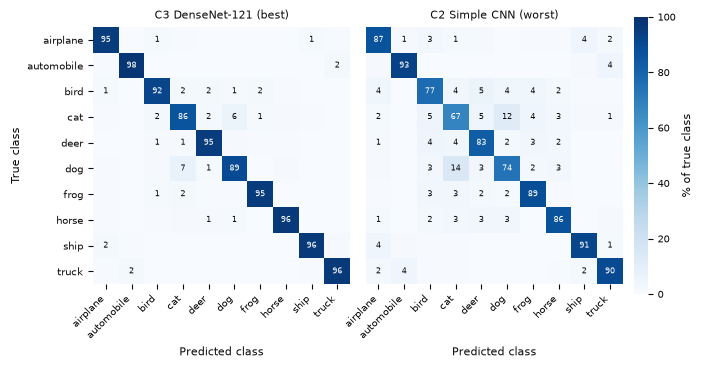

In [22]:
plots.plot_confusion_pair(df, best_id, worst_id);

## 9. Accuracy vs training cost (Fig. 4, optional)

Time per epoch rather than total time, so the comparison stays fair if runs ever differ in length.
All runs used the same GPU, which is what makes the times comparable.

Total GPU time for all 21 runs: 1.36 h


,config_id,num_params,time_per_epoch_mean,train_time_mean,accuracy_mean,accuracy_std
2,C3,6956426,29.9277,748.1930,0.9388,0.0009
0,C1,11173962,6.4419,161.0481,0.9236,0.0027
4,C5,11173962,7.4277,185.6936,0.9215,0.0031
5,C6,11173962,6.0107,150.2663,0.9209,0.0029
6,C7,11173962,5.9990,149.9738,0.9067,0.0046
3,C4,11173962,5.7795,144.4876,0.8637,0.0044
1,C2,620362,3.7758,94.3957,0.8359,0.0034


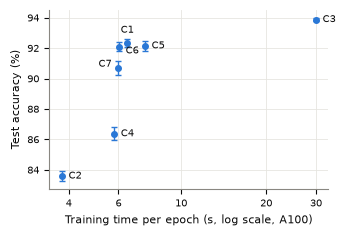

In [23]:
print(f"Total GPU time for all {len(df)} runs: {df['train_time_seconds'].sum() / 3600:.2f} h")
display(summary[["config_id", "num_params", "time_per_epoch_mean", "train_time_mean",
                 "accuracy_mean", "accuracy_std"]].sort_values("accuracy_mean", ascending=False).round(4))
plots.plot_accuracy_vs_cost(summary);